# Implementasi Clustering untuk Menemukan Pola pada Data Pelanggan dengan Metodologi CRISP-DM

**Topik:** Segmentasi Pelanggan Berdasarkan Karakteristik Demografis dan Perilaku

**Dataset:** `Customers.csv`  
**Sumber:** Kaggle – *Shop Customer Clustering* oleh Utkarsh Saxena  
https://www.kaggle.com/code/utkarshsaxenadn/shop-customer-clustering/notebook

Notebook ini disusun ulang mengikuti enam tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment.

## 1. Business Understanding

### Latar Belakang
Data pelanggan memiliki karakteristik yang beragam, seperti usia, pendapatan tahunan, skor pengeluaran, pengalaman kerja, dan ukuran keluarga. Perbedaan tersebut dapat dimanfaatkan untuk menemukan kelompok pelanggan yang memiliki karakteristik serupa.

### Permasalahan
Bagaimana mengelompokkan pelanggan berdasarkan kemiripan karakteristik numeriknya sehingga terbentuk beberapa segmen pelanggan yang dapat dipahami?

### Tujuan
Menerapkan algoritma **K-Means Clustering** untuk menemukan pola pengelompokan pelanggan tanpa menggunakan label kelas yang sudah ditentukan sebelumnya.

### Alasan Dataset Sesuai untuk Clustering
Dataset sesuai untuk clustering karena berisi banyak observasi pelanggan dan memiliki beberapa fitur numerik yang menggambarkan karakteristik pelanggan. Kemiripan nilai pada fitur-fitur tersebut dapat digunakan untuk membentuk kelompok pelanggan.

### Kriteria Keberhasilan
Keberhasilan project dinilai dari terbentuknya cluster yang dapat dianalisis, serta evaluasi menggunakan **Elbow Method, Silhouette Score, Calinski-Harabasz Index, dan Davies-Bouldin Index**.

## 2. Data Understanding

Dataset berasal dari Kaggle dan berbentuk tabular CSV. Dataset digunakan untuk memahami karakteristik pelanggan sebelum dilakukan proses clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

DATA_PATH = 'Customers.csv'
df = pd.read_csv(DATA_PATH)

print('Ukuran dataset:', df.shape)
display(df.head())

Ukuran dataset: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [3]:
print('Jumlah missing value per kolom:')
display(df.isnull().sum().to_frame('Missing Values'))

print('Jumlah baris duplikat:', df.duplicated().sum())

Jumlah missing value per kolom:


,Missing Values
CustomerID,0
Gender,0
Age,0
Annual Income ($),0
Spending Score (1-100),0
Profession,35
Work Experience,0
Family Size,0


Jumlah baris duplikat: 0


### Deskripsi Kolom

- `CustomerID`: identitas pelanggan.
- `Gender`: jenis kelamin pelanggan.
- `Age`: usia pelanggan.
- `Annual Income ($)`: pendapatan tahunan.
- `Spending Score (1-100)`: skor pengeluaran.
- `Profession`: profesi pelanggan.
- `Work Experience`: pengalaman kerja.
- `Family Size`: ukuran keluarga.

Untuk clustering utama, `CustomerID` tidak digunakan karena hanya merupakan identitas. Fitur kategorikal juga tidak digunakan sebagai fitur utama agar clustering berfokus pada karakteristik numerik pelanggan.

In [4]:
numeric_features = [
    'Age',
    'Annual Income ($)',
    'Spending Score (1-100)',
    'Work Experience',
    'Family Size'
]

display(df[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,48.9600,28.429747,0.0,25.0,48.0,73.00,99.0
Annual Income ($),2000.0,110731.8215,45739.536688,0.0,74572.0,110045.0,149092.75,189974.0
Spending Score (1-100),2000.0,50.9625,27.934661,0.0,28.0,50.0,75.00,100.0
Work Experience,2000.0,4.1025,3.922204,0.0,1.0,3.0,7.00,17.0
Family Size,2000.0,3.7685,1.970749,1.0,2.0,4.0,5.00,9.0


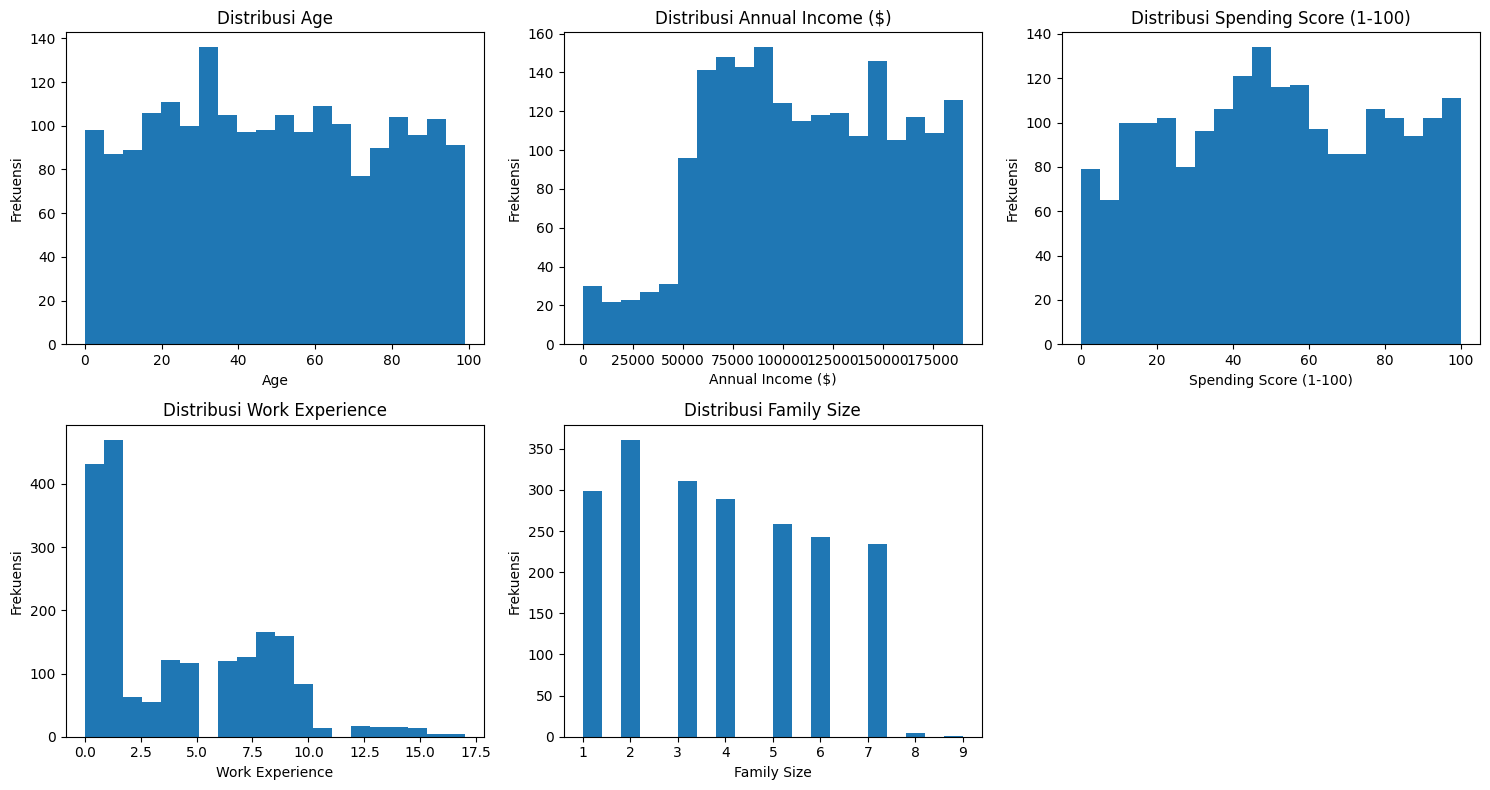

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=20)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 3. Data Preparation

Tahap ini mencakup penanganan missing value, pemilihan fitur, pemeriksaan duplikasi, dan standardisasi. Standardisasi diperlukan karena skala setiap fitur berbeda sehingga fitur dengan nilai numerik lebih besar tidak mendominasi perhitungan jarak K-Means.

In [6]:
# Salin data yang dibutuhkan
data_model = df.copy()

# Isi missing value pada fitur numerik dengan median
for col in numeric_features:
    data_model[col] = data_model[col].fillna(data_model[col].median())

# Hapus duplikasi jika ada
data_model = data_model.drop_duplicates().reset_index(drop=True)

# Data yang digunakan untuk clustering
X = data_model[numeric_features].copy()

print('Ukuran data setelah preparation:', X.shape)
print('Missing value:')
display(X.isnull().sum().to_frame('Missing Values'))

Ukuran data setelah preparation: (2000, 5)
Missing value:


,Missing Values
Age,0
Annual Income ($),0
Spending Score (1-100),0
Work Experience,0
Family Size,0


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)
display(X_scaled_df.head())

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
0,-1.054089,-2.093501,-0.428339,-0.791207,0.117497
1,-0.983723,-1.656133,1.075546,-0.281162,-0.390051
2,-1.018906,-0.540845,-1.609962,-0.791207,-1.405148
3,-0.913356,-1.131292,0.932319,-1.046230,-0.897599
4,-0.631891,-1.590528,-0.392532,-0.536185,1.132594


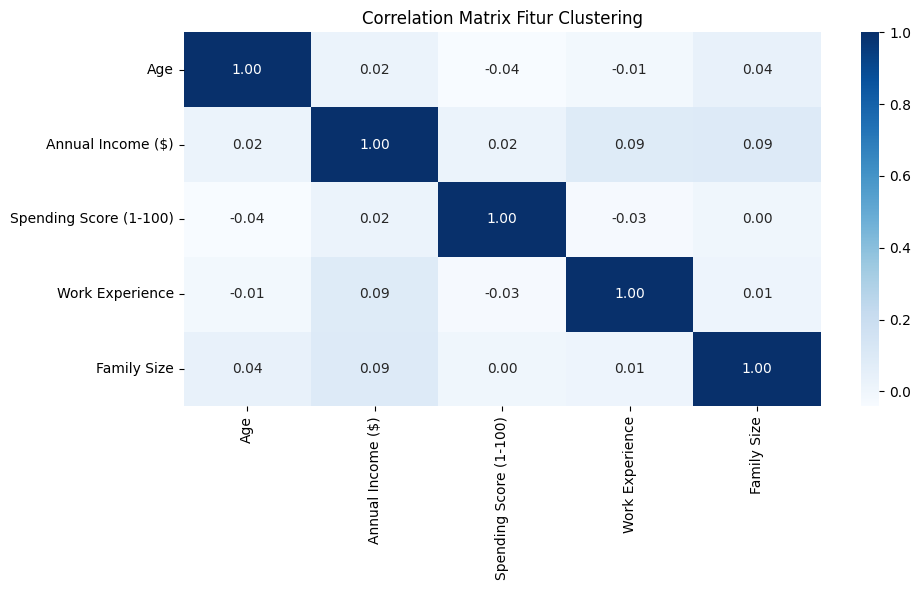

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(X_scaled_df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix Fitur Clustering')
plt.tight_layout()
plt.show()

## 4. Modeling

Algoritma utama yang digunakan adalah **K-Means Clustering**. Beberapa nilai `k` diuji terlebih dahulu untuk membantu menentukan jumlah cluster yang sesuai.

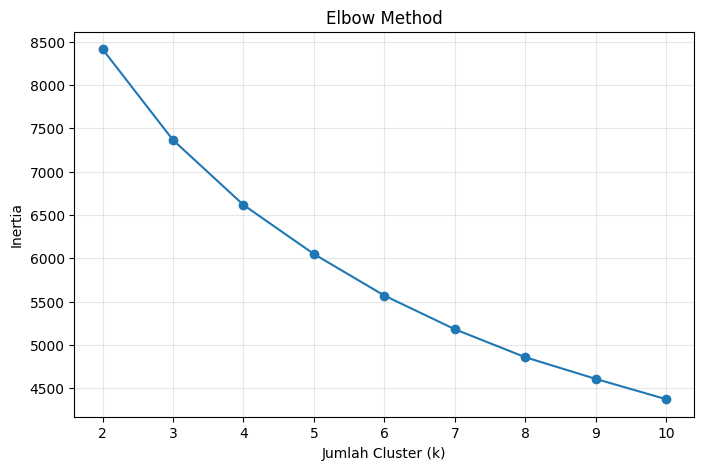

In [9]:
# Menguji beberapa nilai k dengan Elbow Method
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Evaluasi beberapa nilai k
evaluation = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    evaluation.append({
        'k': k,
        'Silhouette Score': silhouette_score(X_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, labels),
        'Inertia': model.inertia_
    })

evaluation_df = pd.DataFrame(evaluation)
display(evaluation_df.round(4))

,k,Silhouette Score,Calinski-Harabasz,Davies-Bouldin,Inertia
0,2,0.1607,376.6624,2.2151,8413.8405
1,3,0.1540,357.2380,1.8792,7364.9926
2,4,0.1481,340.3945,1.7167,6615.4858
3,5,0.1562,325.8630,1.5832,6048.3070
4,6,0.1588,317.3628,1.5233,5568.5852
5,7,0.1628,309.1047,1.5122,5179.8146
6,8,0.1677,301.3384,1.4291,4856.9463
7,9,0.1677,291.4035,1.4137,4606.4397
8,10,0.1739,284.6469,1.3995,4371.8758


### Model K-Means Final

Berdasarkan pola Elbow Method dan kebutuhan segmentasi pelanggan yang tetap mudah diinterpretasikan, project menggunakan **5 cluster**. Nilai evaluasi untuk `k=5` tetap ditampilkan sebagai dasar penilaian model.

In [11]:
FINAL_K = 5

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
data_model['Cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, data_model['Cluster'])
final_calinski = calinski_harabasz_score(X_scaled, data_model['Cluster'])
final_davies = davies_bouldin_score(X_scaled, data_model['Cluster'])

print('Jumlah cluster:', FINAL_K)
print('Silhouette Score:', round(final_silhouette, 4))
print('Calinski-Harabasz Index:', round(final_calinski, 4))
print('Davies-Bouldin Index:', round(final_davies, 4))

Jumlah cluster: 5
Silhouette Score: 0.1562
Calinski-Harabasz Index: 325.863
Davies-Bouldin Index: 1.5832


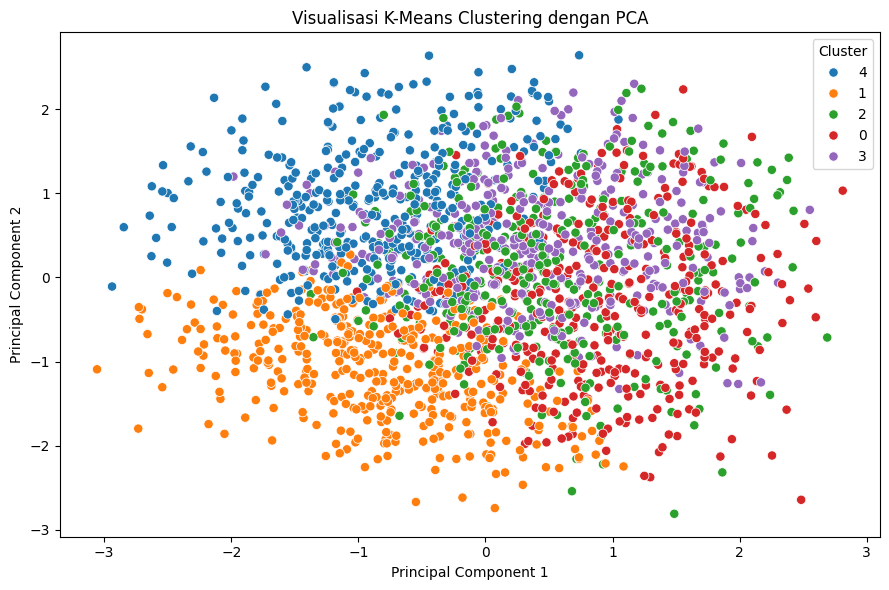

Proporsi variance PCA: [0.2282 0.2085]


In [12]:
# Visualisasi cluster menggunakan PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': data_model['Cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=45)
plt.title('Visualisasi K-Means Clustering dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print('Proporsi variance PCA:', np.round(pca.explained_variance_ratio_, 4))

## 5. Evaluation

Evaluasi dilakukan menggunakan beberapa metrik internal clustering:

- **Silhouette Score:** semakin mendekati 1 menunjukkan pemisahan cluster yang semakin baik.
- **Calinski-Harabasz Index:** nilai yang lebih tinggi menunjukkan pemisahan antar-cluster relatif lebih baik.
- **Davies-Bouldin Index:** nilai yang lebih rendah menunjukkan cluster yang relatif lebih kompak dan terpisah.
- **Elbow Method:** digunakan untuk melihat perubahan inertia ketika jumlah cluster bertambah.

Hasil evaluasi harus dibaca bersama visualisasi dan kebutuhan segmentasi, bukan hanya berdasarkan satu metrik.

In [13]:
# Ukuran setiap cluster
cluster_counts = data_model['Cluster'].value_counts().sort_index()
cluster_percent = (cluster_counts / len(data_model) * 100).round(2)

cluster_summary = pd.DataFrame({
    'Jumlah Pelanggan': cluster_counts,
    'Persentase (%)': cluster_percent
})

display(cluster_summary)

,Jumlah Pelanggan,Persentase (%)
Cluster,,
0,384,19.20
1,413,20.65
2,379,18.95
3,407,20.35
4,417,20.85


In [14]:
# Profil rata-rata setiap cluster
cluster_profile = data_model.groupby('Cluster')[numeric_features].mean().round(2)
display(cluster_profile)

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
Cluster,,,,,
0,32.27,133657.09,46.48,4.26,6.13
1,27.08,98701.66,76.77,3.02,2.60
2,54.27,121610.54,38.22,9.17,2.78
3,80.40,120598.18,67.69,2.83,4.45
4,50.48,82018.42,24.78,1.66,2.98


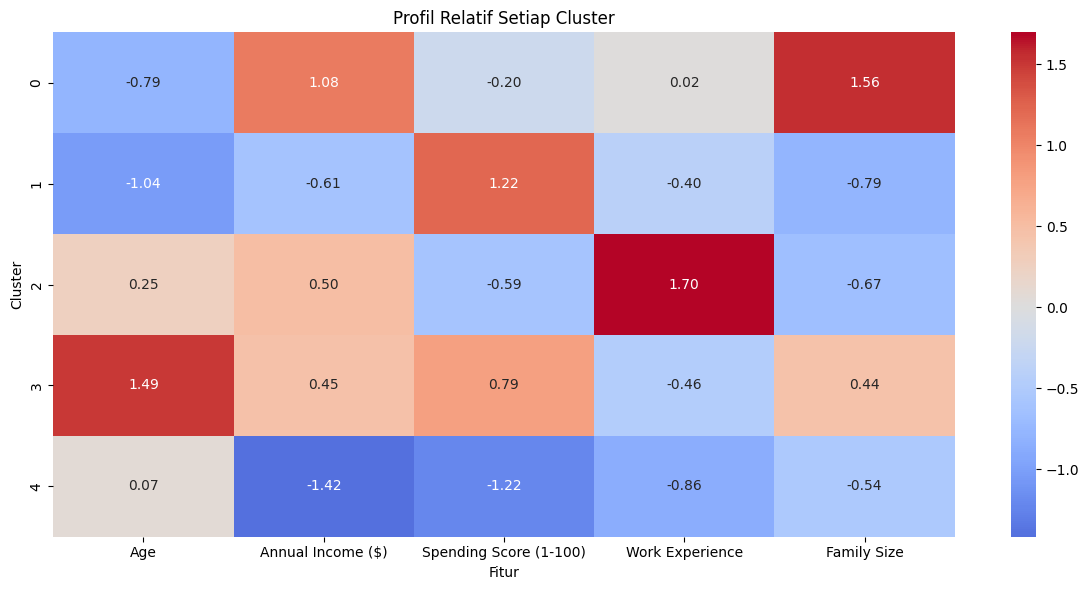

In [15]:
# Visualisasi profil cluster
profile_scaled = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

plt.figure(figsize=(12, 6))
sns.heatmap(profile_scaled, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Profil Relatif Setiap Cluster')
plt.xlabel('Fitur')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

### Interpretasi Hasil

Cluster yang terbentuk menggambarkan kelompok pelanggan berdasarkan kombinasi usia, pendapatan tahunan, skor pengeluaran, pengalaman kerja, dan ukuran keluarga. Profil rata-rata setiap cluster digunakan untuk melihat karakteristik yang membedakan kelompok.

Interpretasi akhir sebaiknya menggunakan nilai rata-rata pada tabel `cluster_profile`, sehingga nama atau deskripsi segmen diberikan berdasarkan data hasil clustering dan bukan berdasarkan asumsi sebelum model dijalankan.

## 6. Deployment

Tahap deployment pada project ini dilakukan dalam bentuk penyimpanan model dan scaler agar model clustering dapat digunakan kembali pada data pelanggan baru.

Model tidak hanya disimpan sebagai hasil analisis, tetapi juga disertai `StandardScaler` karena data baru harus melalui transformasi yang sama sebelum masuk ke K-Means.

In [16]:
import joblib

MODEL_FILE = 'kmeans_customer_segmentation.joblib'
SCALER_FILE = 'customer_scaler.joblib'

joblib.dump(kmeans, MODEL_FILE)
joblib.dump(scaler, SCALER_FILE)

print('Model tersimpan:', MODEL_FILE)
print('Scaler tersimpan:', SCALER_FILE)

Model tersimpan: kmeans_customer_segmentation.joblib
Scaler tersimpan: customer_scaler.joblib


In [17]:
# Contoh penggunaan model untuk satu pelanggan baru
sample_customer = pd.DataFrame([{
    'Age': 35,
    'Annual Income ($)': 70000,
    'Spending Score (1-100)': 65,
    'Work Experience': 8,
    'Family Size': 3
}])

sample_scaled = scaler.transform(sample_customer[numeric_features])
predicted_cluster = kmeans.predict(sample_scaled)[0]

print('Cluster pelanggan baru:', predicted_cluster)

Cluster pelanggan baru: 1


## Kesimpulan

Project clustering ini telah disusun mengikuti enam tahapan CRISP-DM:

1. **Business Understanding** — menentukan tujuan segmentasi pelanggan.
2. **Data Understanding** — memahami struktur, karakteristik, dan kondisi dataset.
3. **Data Preparation** — menangani missing value, memilih fitur numerik, dan melakukan standardisasi.
4. **Modeling** — menerapkan K-Means dan menentukan jumlah cluster dengan bantuan Elbow Method serta metrik clustering.
5. **Evaluation** — mengevaluasi hasil menggunakan Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index, distribusi cluster, dan profil cluster.
6. **Deployment** — menyimpan model K-Means dan scaler serta memberikan contoh prediksi cluster untuk data pelanggan baru.

Dengan demikian, notebook dapat digunakan sebagai project Data Science sederhana untuk menemukan pola dan segmentasi pada data pelanggan.